In [2]:
from sklearn import datasets
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv(r'C:\Users\Phillip\Desktop\Python\Python Notebooks (Mine)\Datasets\Iris.csv', index_col = 'Id')
df.rename(columns = {'SepalLengthCm' : 'SepalLength',
                    'SepalWidthCm' : 'SepalWidth',
                    'PetalLengthCm' : 'PetalLength',
                    'PetalWidthCm' : 'PetalWidth'},
                    inplace = True)

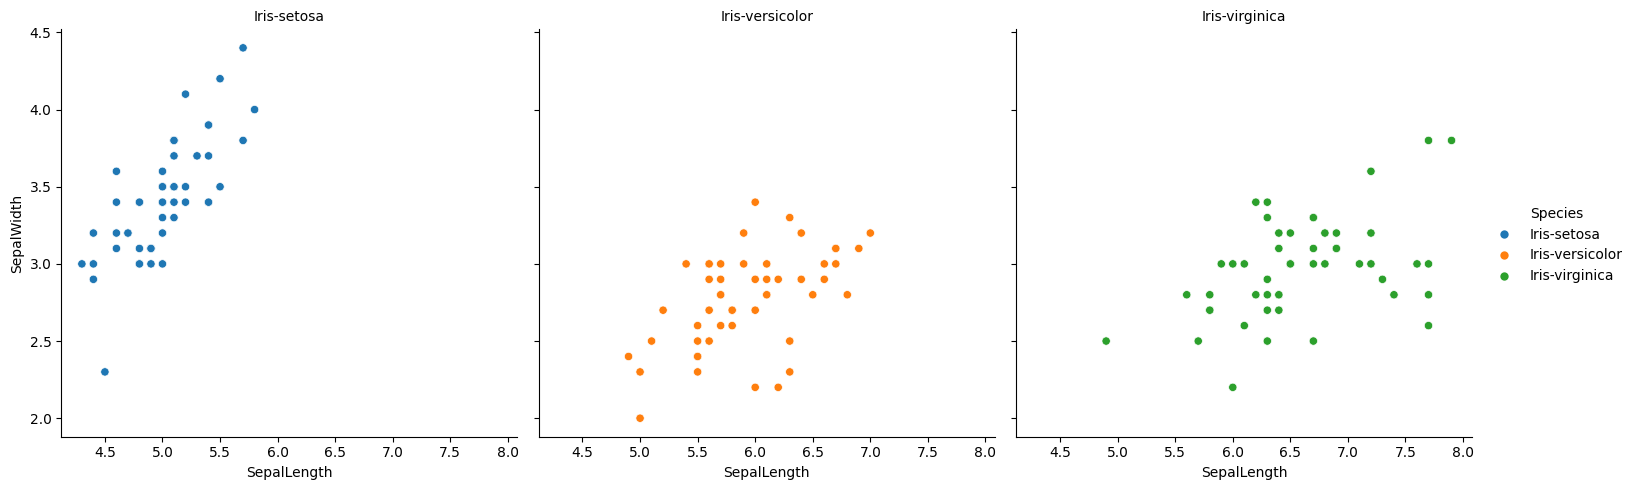

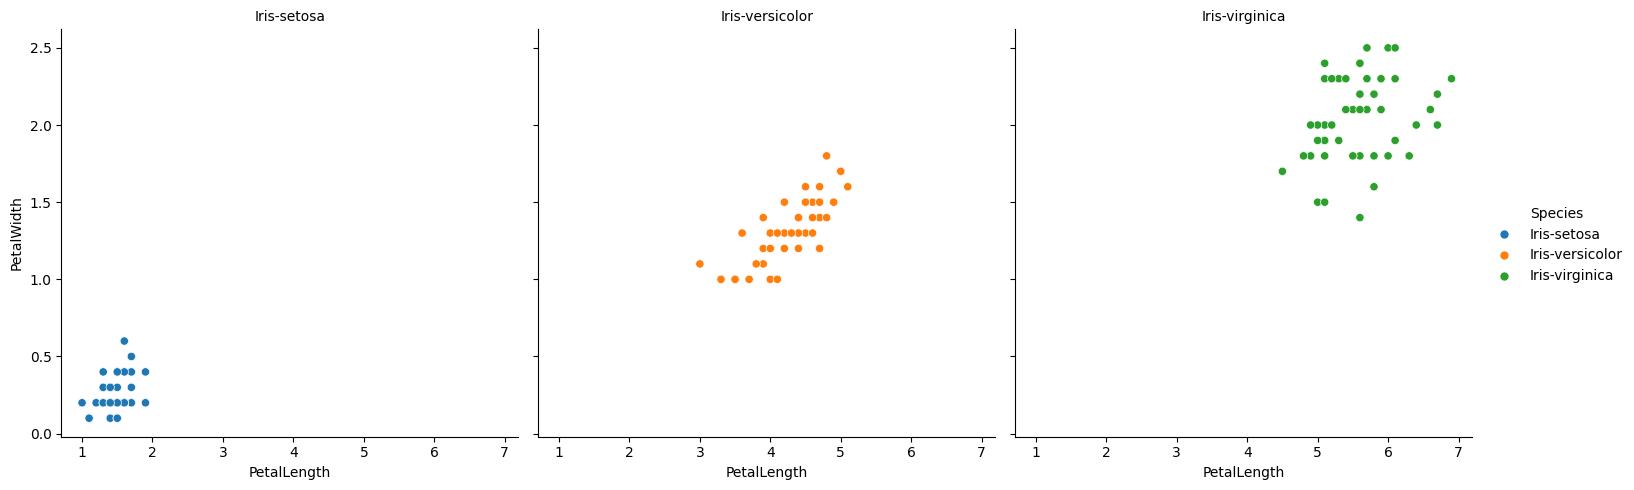

In [4]:
# Relplot is figure level => multiple sub plots. 
# g is the FacetGrid containing 3 axis

g = sns.relplot(
    data = df,
    x = "SepalLength",
    y = "SepalWidth",
    hue = 'Species', 
    col = "Species", # How many subplots, can also use row
    kind = "scatter"
)

# Use {col_name} -> make sure its set_titles not set_title
g.set_titles('{col_name}') 

f = sns.relplot(
    data = df,
    x = "PetalLength",
    y = "PetalWidth",
    hue = 'Species', 
    col = "Species", # How many subplots, can also use row
    kind = "scatter"
)

# Use {col_name} -> make sure its set_titles not set_title
f.set_titles('{col_name}') 


<Figure size 1000x600 with 0 Axes>

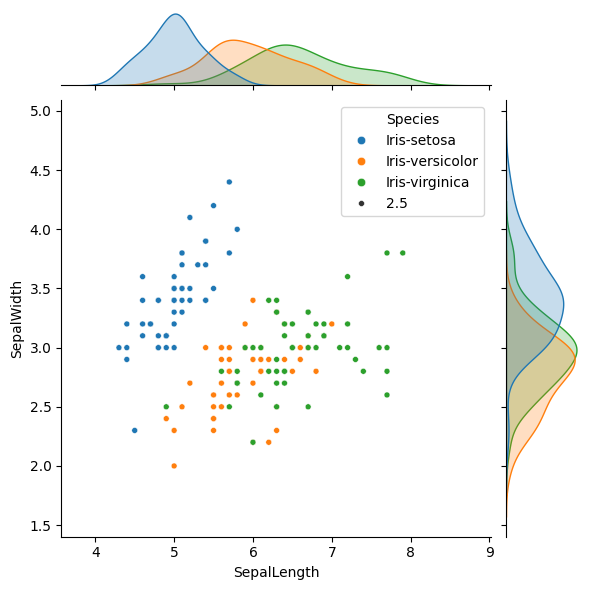

In [5]:
# Do joint histogram
plt.figure(figsize = (10,6))

sns.jointplot(data = df,
                  x = 'SepalLength',
                  y = 'SepalWidth',
                  size = 2.5,
                  hue = 'Species'
                  )

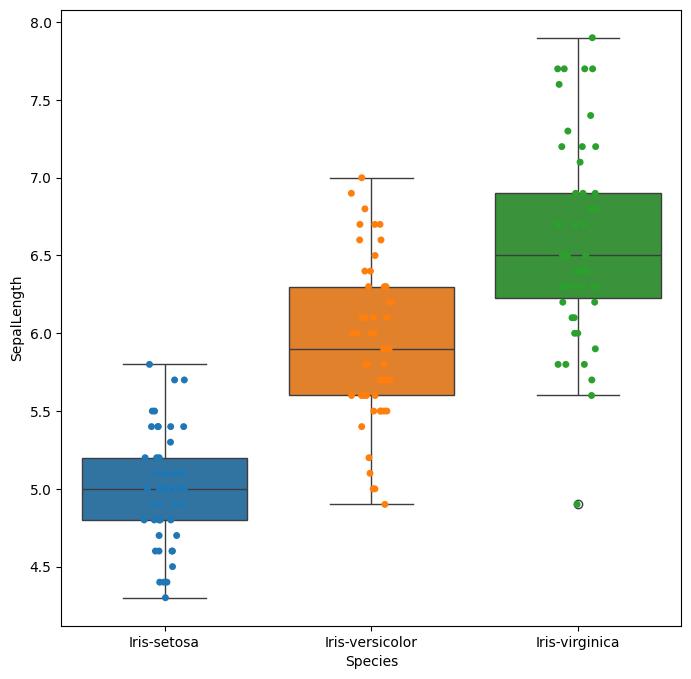

In [6]:
plt.figure(figsize = (8,8))

# Can do boxplot to see median, mean, and IQR
g = sns.boxplot(data = df,
            x = 'Species',
            y = 'SepalLength',
            hue = 'Species')

# Can add layer of individual points through stripplot

g = sns.stripplot(data = df,
                x = 'Species',
                y = 'SepalLength',
                jitter = True,
                hue = 'Species'
                )


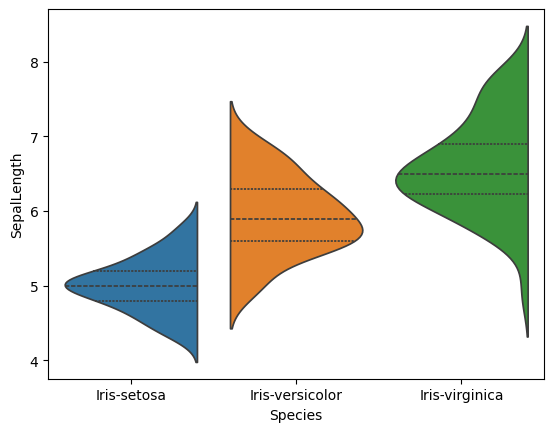

In [7]:
# Violin plot combines the benefits of two plots and simplifies it
# Denser area -> where data is more present
# Violin plots are boxplot + KDE

g = sns.violinplot(data = df,
                   x = 'Species',
                   y = 'SepalLength',
                   hue = 'Species',
                   split = True, # When hue is used -> splits violin in half
                   inner = 'quartiles', # Can show the box or points or none
                   density_norm = 'area' # what
                   )

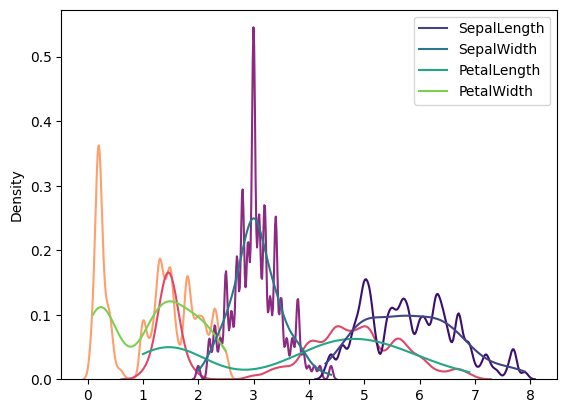

In [8]:
# Can do a KDE of the underlying feature by using a plot useful for
# understanding univariate relationships

g = sns.kdeplot(data = df,
                bw_adjust = 0.2, # Adjust smoothing
                palette = 'magma')

                
g = sns.kdeplot(data = df,
                bw_adjust = 1, # Adjust smoothing
                cut = 0, # Do not pass extreme data points
                palette = 'viridis')

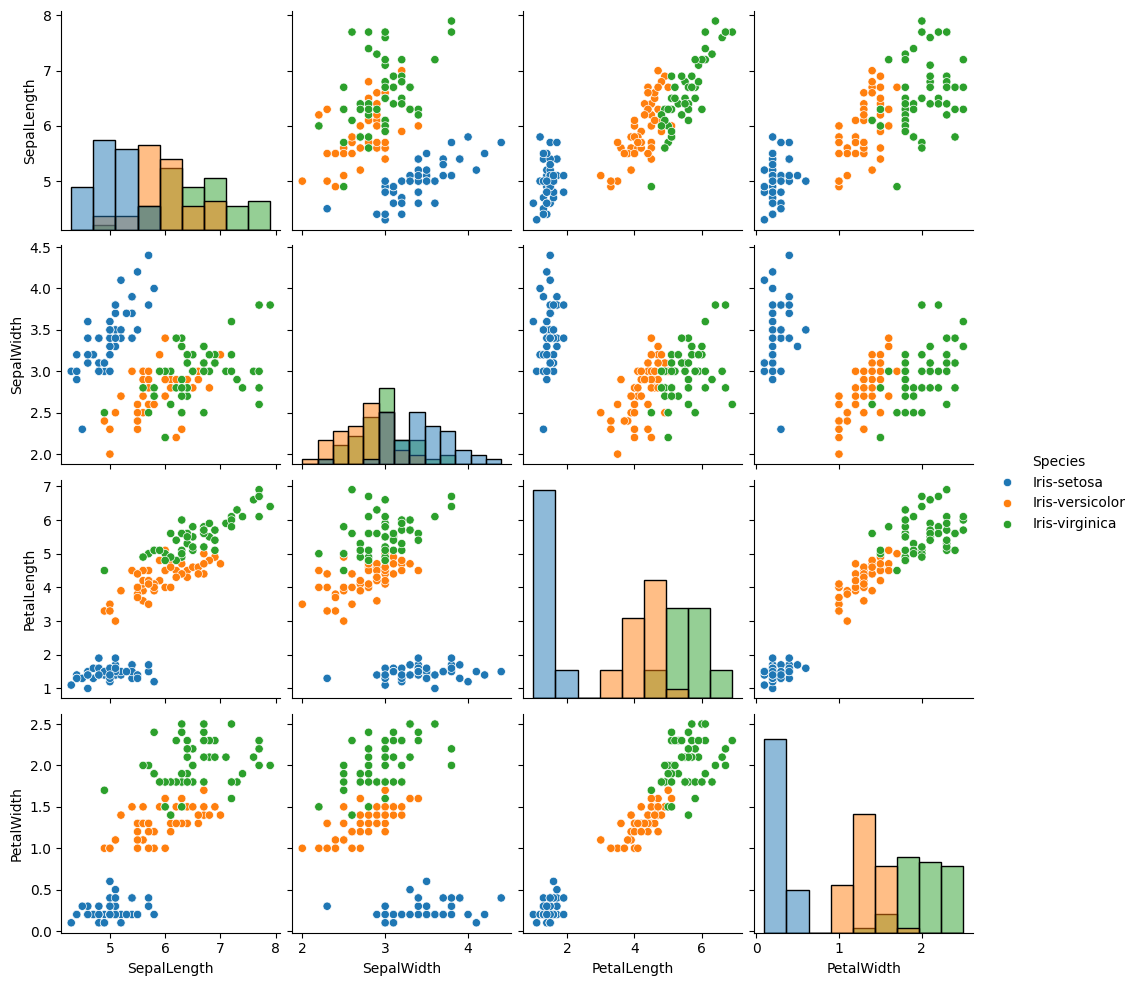

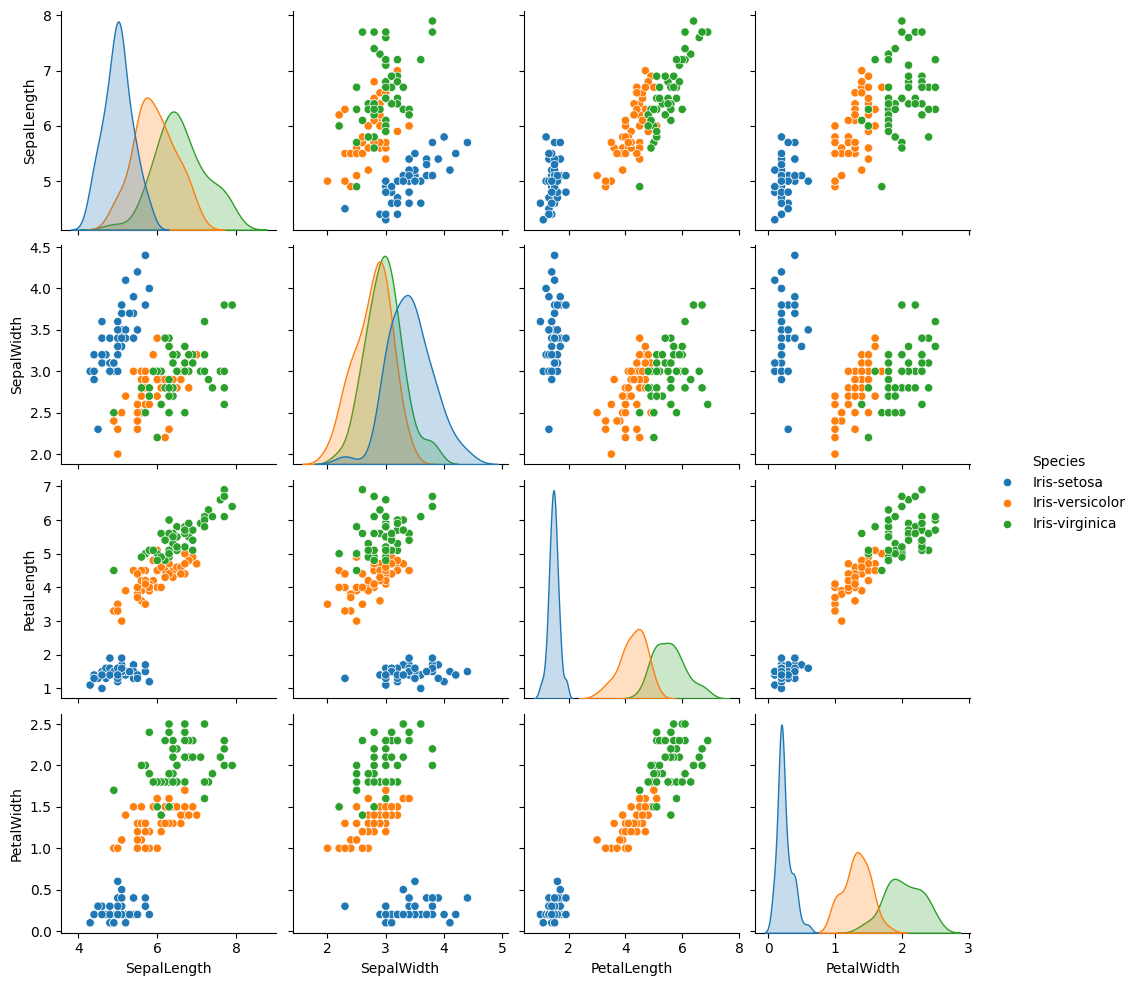

In [14]:
# Bivariate relationship between all pairs of features 
bar = sns.pairplot(data = df,
             hue = 'Species',
             diag_kind='hist')

kde = sns.pairplot(data = df,
                   hue = 'Species',
                   diag_kind = 'kde')

array([[<Axes: title={'center': 'PetalLength'}, xlabel='[Species]'>,
        <Axes: title={'center': 'PetalWidth'}, xlabel='[Species]'>],
       [<Axes: title={'center': 'SepalLength'}, xlabel='[Species]'>,
        <Axes: title={'center': 'SepalWidth'}, xlabel='[Species]'>]],
      dtype=object)

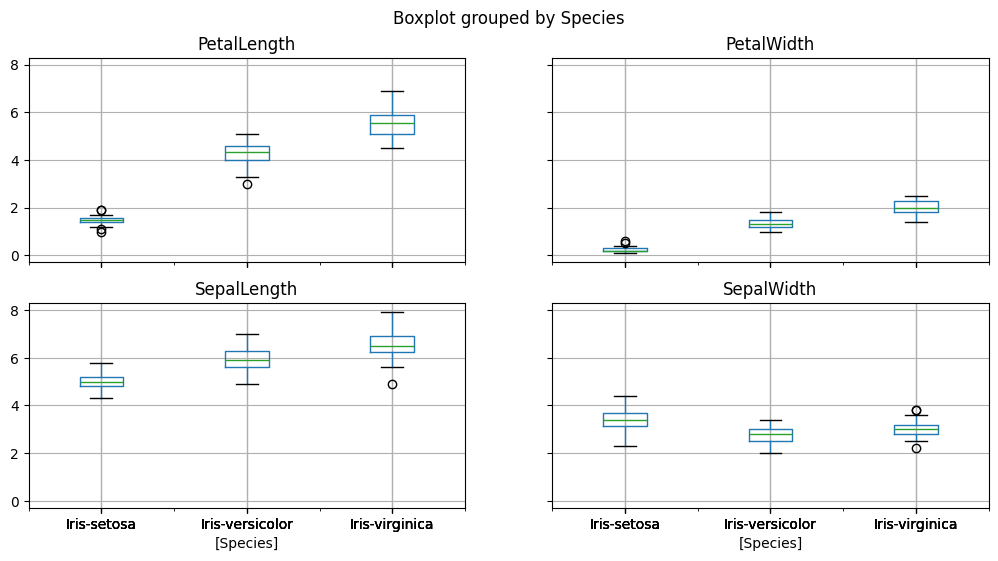

In [ ]:
# Can boxplot from Pandas for each feature, specify the label (species) using by

df.boxplot(by = 'Species',
           figsize = (12,6)
           )

Text(0.5, 1.0, 'RADVIZ')

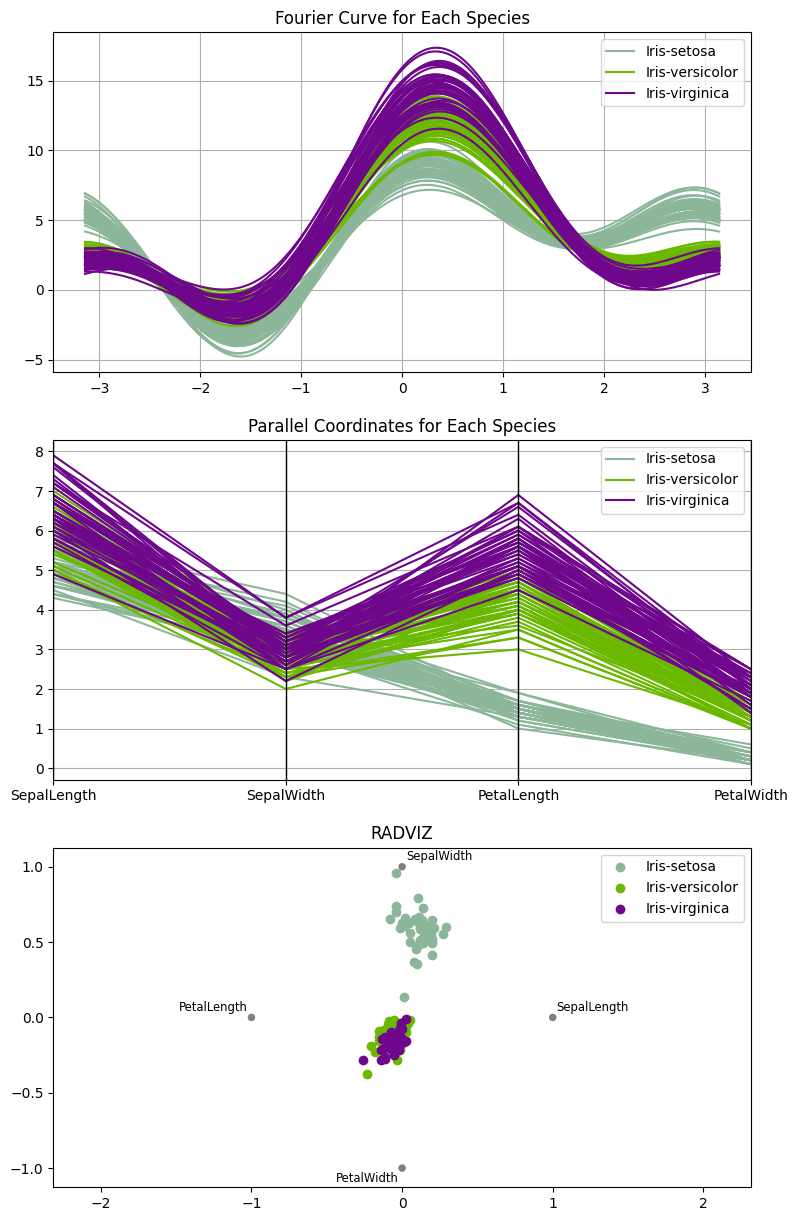

In [27]:
# Andrews Curves (Fourier Series using attributes of samples for coefficients)
from pandas.plotting import andrews_curves, radviz, parallel_coordinates

fig, axs = plt.subplots(3,1, figsize = (9, 15))

# Useful for generating visualisations of multivariate clustering issues
andrews_curves(frame = df,
                ax = axs[0],
               class_column='Species',
               )
axs[0].set_title('Fourier Curve for Each Species')

# Parallel coordinates plots each feature on separate columns then draws lines connecting features for each data sample

parallel_coordinates(frame = df,
                     ax = axs[1],
                     class_column='Species')

axs[1].set_title('Parallel Coordinates for Each Species')

# Final multivariate visualisation plots each feature on a 2D plane
# then simulates via a spring which is weighted by the relative value attached 
# to those points for that feature

radviz(frame= df, ax = axs[2], class_column='Species')
axs[2].set_title('RADVIZ')